## Pipeline comparisson

This notebook is to check that running heracles on Euclid data *outside* the pipeline matches the data produced when running *inside* the pipleine 

## params and input files

In [15]:
nside = 1024
lmin = 10
lmax = 1500
nlbins = 30

In [16]:
import matplotlib.pyplot as plt
import heracles
from camb.sources import SplinedSourceWindow
from scipy.stats import chi2 as chi2_dist
import healpy as hp
DATA_DIR = "pipeline_input"


vmaps = []

for i in range(1, 7):
    fname = f"{DATA_DIR}/vis_TR1_B_NORTH_v1_1_nsystmax_5_1024_{i}.fits"
    vmap = hp.read_map(fname)
    # fix UNSEEN pixels
    vmap[vmap == hp.UNSEEN] = 0.0
    # rescale to desired nside
    vmap = hp.ud_grade(vmap, 2 * nside)
    vmaps.append(vmap)


#### read map (alternative to heracles.read_map)

In [17]:
import fitsio
import numpy as np
import healpy as hp
def read_map(path, nside, *, nest=False):
    """
    Read a HEALPix map in "partial" format from *path* and return it at
    resolution *nside*.
    The returned NSIDE cannot be larger than the NSIDE of the stored
    map.
    If *nest* is true, returns the map in NESTED ordering.
    """
    data, header = fitsio.read(path, header=True)
    nside_in = header["NSIDE"]
    fact = (nside_in // nside) ** 2
    if fact == 0:
        raise ValueError(
            f"requested NSIDE={nside} greater than map NSIDE={nside_in}"
        )
    out = np.zeros(12 * nside**2)
    ipix, wht = data["PIXEL"], data["WEIGHT"]
    order = header["ORDERING"]
    if order == "RING":
        ipix = hp.ring2nest(nside, ipix)
    elif order != "NESTED":
        raise ValueError(f"unknown pixel ordering {order} in map")
    ipix = ipix // fact
    if not nest:
        ipix = hp.nest2ring(nside, ipix)
    np.add.at(out, ipix, wht / fact)
    return out

### cats + coverage

In [18]:
fname = f"{DATA_DIR}/EUC_LE3_VMPZ-ID_HPEFFECTIVECOVERAGE-CONCAT-20251204T094108.787432Z_0.12.fits"
coverage = read_map(fname, nside)
coverage[coverage == hp.UNSEEN] = 0.0
coverage = hp.ud_grade(coverage, 2 * nside)

In [19]:
catalogPos = heracles.FitsCatalog(f"{DATA_DIR}/EUC_LE3_POSCATALOG-CONCAT-20251217T102340.183376Z_00.00.fits")
catalogShe = heracles.FitsCatalog(f"{DATA_DIR}/EUC_LE3_WLCATALOG-CONCAT-20251218T164508.418188Z_00.00.fits")

## plot visibility and coverage

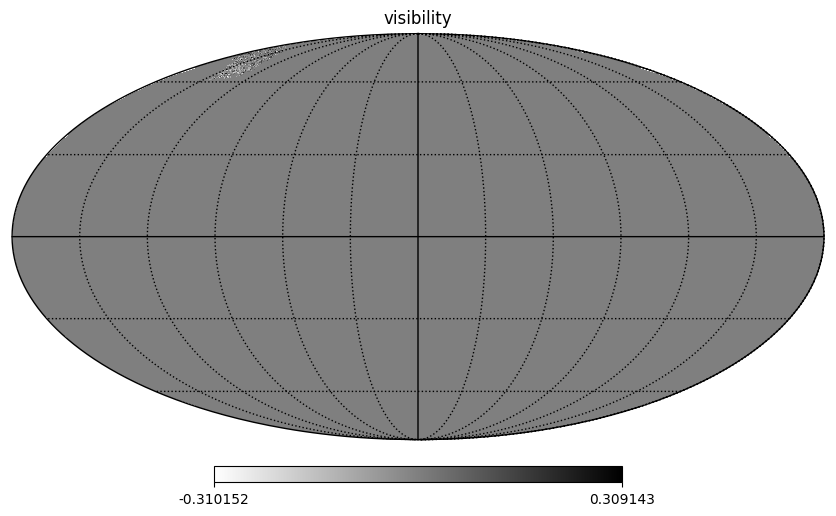

In [20]:
hp.mollview(vmaps[5], title="visibility", cmap="binary", bgcolor="none")
hp.graticule()
plt.show()

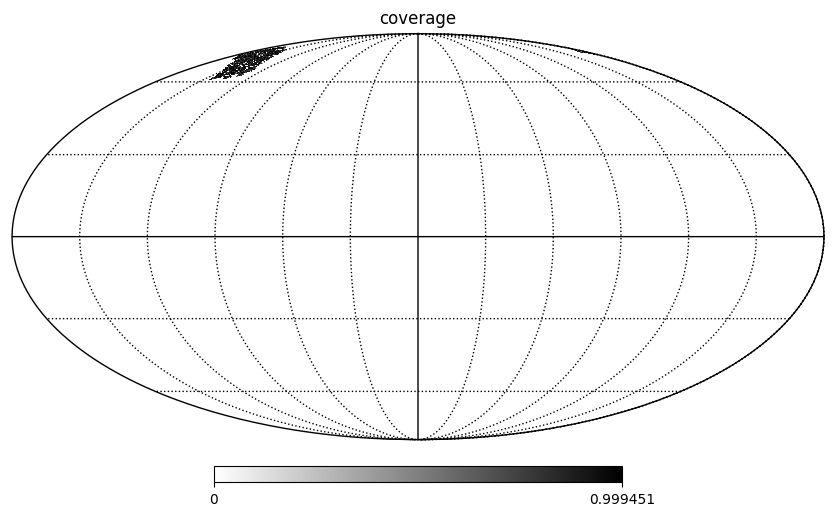

In [21]:
hp.mollview(coverage, title="coverage", cmap="binary", bgcolor="none")
hp.graticule()
plt.show()

## Create maps, alms cls

### Define the fields to be mapped and transformed

In [22]:
pos_bins = {i: catalogPos[f"POS_TOM_BIN_ID == {i}"] for i in range(1, 7)}
she_bins = {i: catalogShe[f"TOM_BIN_ID == {i}"] for i in range(1, 7)}

In [23]:
pos_catalogs = {}
she_catalogs = {}

for i in range(1, 7):
    pos_cat = pos_bins[i]
    she_cat = she_bins[i]
    vmap = vmaps[i - 1]
    she_cat.visibility = coverage
    pos_cat.visibility = coverage * (1.0 + vmap)
    pos_catalogs[i] = pos_cat
    she_catalogs[i] = she_cat


In [24]:
import heracles.healpy
mapper = heracles.healpy.HealpixMapper(nside, lmax)

In [25]:
fieldsPos = {
    "POS": heracles.Positions(
        mapper,
        "RIGHT_ASCENSION",
        "DECLINATION",
        mask="VIS",
    ),
    "VIS": heracles.Visibility(mapper),
}

fieldsShe = {
    "SHE": heracles.Shears(
        mapper,
        "SHE_RA",
        "SHE_DEC",
        "-SHE_E1_CORRECTED",
        "SHE_E2_CORRECTED",
        "SHE_WEIGHT",
        mask="WHT",
    ),
    "WHT": heracles.Weights(
        mapper,
        "SHE_RA",
        "SHE_DEC",
        "SHE_WEIGHT",
    ),
}


### map catalogs seperately

In [26]:
data_pos = heracles.map_catalogs(fieldsPos,  pos_catalogs,  parallel=True)

/home/vscode/.local/lib/python3.10/site-packages/heracles/fields.py:494: UserWarning: changing size of visibility map
  warnings.warn("changing size of visibility map")
/home/vscode/.local/lib/python3.10/site-packages/heracles/fields.py:302: UserWarning: positions and visibility have different size
  warnings.warn("positions and visibility have different size")


In [27]:
data_she = heracles.map_catalogs(fieldsShe, she_catalogs, parallel=True)

In [28]:
alms_pos = heracles.transform(fieldsPos, data_pos)

In [29]:
alms_she = heracles.transform(fieldsShe, data_she)

In [30]:
alms = {}
alms.update(alms_pos)
alms.update(alms_she)

In [31]:
cls = heracles.angular_power_spectra(
        alms,
        include=[
            ("POS", "POS"),
            ("POS", "SHE"),
            ("SHE", "SHE"),
        ],
    )

In [32]:
ledges = np.logspace(np.log10(10), np.log10(lmax), nlbins + 1)
cls_binned = heracles.binned(cls, ledges)


#### mixing matrices

In [33]:
fields = {**fieldsPos, **fieldsShe}

In [34]:
cls = heracles.angular_power_spectra(
        alms,
        include=[
            ("VIS", "VIS"),
            ("VIS", "WHT"),
            ("WHT", "WHT"),
        ],
    ) 
ledges = np.logspace(np.log10(10), np.log10(lmax), nlbins + 1)
mms = heracles.mixing_matrices(fields, cls, bins=ledges)

## Compare with pipeline

In [39]:
DATA_DIR = "pipeline_output"
CLS_FILE = f"{DATA_DIR}/EUC_LE3_PKWL-SPECTRA-BINNED_1708440_20260414T135912.860079Z_26.02.fits"
cls_pipe = heracles.read(CLS_FILE)
mms_pipe = heracles.read(f"{DATA_DIR}/EUC_LE3_PKWL-MIXMATS_2010523_20260414T140030.488345Z_26.02.fits")

### mixing matrices compare 

In [40]:
lmax_pipe  = int(mms_pipe["POS", "POS", 1, 1].shape[-1]) - 1  # l2-extent of mixing matrix
lmax_script  = int(mms["POS", "POS", 1, 1].shape[-1]) - 1  # l2-extent of mixing matrix
print(f"l2 max pipeline : {lmax_pipe}")
print(f"l2 max script   : {lmax_script}")

l2 max pipeline : 1500
l2 max script   : 1500


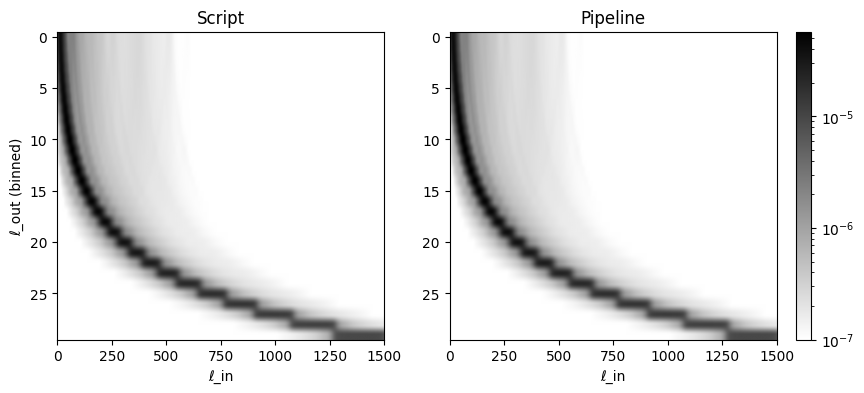

In [41]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

mm_script = mms["SHE", "SHE", i, i]
mm_pipe   = mms_pipe["SHE", "SHE", i, i]

# extract EE blocks
M_script = np.array(mm_script[0])
M_pipe   = np.array(mm_pipe[0])

# shared color scale
vmin = 1e-7
vmax = max(M_script.max(), M_pipe.max())

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# --- script ---
im0 = axes[0].imshow(
    M_script,
    cmap="binary",
    norm=mpl.colors.LogNorm(vmin=vmin, vmax=vmax),
    aspect="auto"
)
axes[0].set_title("Script")
axes[0].set_xlabel("ℓ_in")
axes[0].set_ylabel("ℓ_out (binned)")

# --- pipeline ---
im1 = axes[1].imshow(
    M_pipe,
    cmap="binary",
    norm=mpl.colors.LogNorm(vmin=vmin, vmax=vmax),
    aspect="auto"
)
axes[1].set_title("Pipeline")
axes[1].set_xlabel("ℓ_in")

# shared colorbar
fig.colorbar(im1, ax=axes, pad=0.025, fraction=0.0465)

plt.show()

In [38]:
def compare_mm(mm1, mm2, kind="scalar", name=""):
    A = np.array(mm1)
    B = np.array(mm2)

    print(f"\n--- {name} ---")
    print("Shape:", A.shape, B.shape)

    if not np.allclose(A.shape, B.shape):
        print("❌ Shape mismatch")
        return

    def check(a, b, label):
        ok = np.allclose(a, b, rtol=1e-5, atol=1e-10)
        rel = np.abs((a - b) / (b + 1e-30))
        print(f"{label}: allclose={ok}, mean={rel.mean():.2e}, max={rel.max():.2e}")

    if kind == "scalar":
        check(A, B, "POS×POS")

    elif kind == "shear":
        # (3, ℓ_out, ℓ_in) → [EE, BB, EB]
        check(A[0], B[0], "EE")
        check(A[1], B[1], "BB")
        # optional
        check(A[2], B[2], "EB/BE")

    elif kind == "cross":
        # (1 or 2, ℓ_out, ℓ_in) → E mode is index 0
        check(A[0], B[0], "POS×SHE (E)")

    else:
        raise ValueError("Unknown kind")


In [42]:
for i in range(1, 7):
    for j in range(1, 7):

        if ("POS","POS",i,j) in mms:
            compare_mm(
                mms["POS","POS",i,j],
                mms_pipe["POS","POS",i,j],
                kind="scalar",
                name=f"POS×POS ({i},{j})"
            )

        if ("SHE","SHE",i,j) in mms:
            compare_mm(
                mms["SHE","SHE",i,j],
                mms_pipe["SHE","SHE",i,j],
                kind="shear",
                name=f"SHE×SHE ({i},{j})"
            )

        if ("POS","SHE",i,j) in mms:
            compare_mm(
                mms["POS","SHE",i,j],
                mms_pipe["POS","SHE",i,j],
                kind="cross",
                name=f"POS×SHE ({i},{j})"
            )



--- POS×POS (1,1) ---
Shape: (30, 1501) (30, 1501)
POS×POS: allclose=True, mean=1.08e-18, max=5.22e-16

--- SHE×SHE (1,1) ---
Shape: (3, 30, 1501) (3, 30, 1501)
EE: allclose=True, mean=1.02e-07, max=1.16e-07
BB: allclose=True, mean=1.02e-07, max=1.17e-07
EB/BE: allclose=True, mean=1.02e-07, max=1.16e-07

--- POS×SHE (1,1) ---
Shape: (30, 1501) (30, 1501)
POS×SHE (E): allclose=True, mean=4.85e-08, max=4.86e-08

--- POS×POS (1,2) ---
Shape: (30, 1501) (30, 1501)
POS×POS: allclose=True, mean=5.05e-19, max=4.93e-16

--- SHE×SHE (1,2) ---
Shape: (3, 30, 1501) (3, 30, 1501)
EE: allclose=True, mean=3.94e-08, max=3.95e-08
BB: allclose=True, mean=3.94e-08, max=3.95e-08
EB/BE: allclose=True, mean=3.94e-08, max=3.95e-08

--- POS×SHE (1,2) ---
Shape: (30, 1501) (30, 1501)
POS×SHE (E): allclose=True, mean=9.10e-09, max=9.12e-09

--- POS×POS (1,3) ---
Shape: (30, 1501) (30, 1501)
POS×POS: allclose=True, mean=1.11e-18, max=4.98e-16

--- SHE×SHE (1,3) ---
Shape: (3, 30, 1501) (3, 30, 1501)
EE: allclo

### spectra compare

In [43]:
print(f"Cls (script)   : {len(cls_binned)} spectra")
print(f"Cls (pipeline) : {len(cls_pipe)} spectra")


def compare_spectrum(key, mode=None):
    print(f"\n--- Checking {key} ---")

    if key not in cls_binned:
        print("Missing in script")
        return
    if key not in cls_pipe:
        print("Missing in pipeline")
        return

    v_script = cls_binned[key]
    v_pipe   = cls_pipe[key]

    # ℓ arrays
    ell_script = np.array(v_script.ell)
    ell_pipe   = np.array(v_pipe.ell)

    print(f"Ell bins (script)   : {len(ell_script)} "
          f"(ℓ = {ell_script[0]:.1f} – {ell_script[-1]:.1f})")

    print(f"Ell bins (pipeline) : {len(ell_pipe)} "
          f"(ℓ = {ell_pipe[0]:.1f} – {ell_pipe[-1]:.1f})")

    print("Ell arrays equal? :", np.allclose(ell_script, ell_pipe))

    # --- extract data depending on type ---
    if key[0] == "SHE" and key[1] == "SHE":
        # need mode selection
        if mode == "EE":
            d_script = np.array(v_script[0, 0])
            d_pipe   = np.array(v_pipe[0, 0])
        elif mode == "BB":
            d_script = np.array(v_script[1, 1])
            d_pipe   = np.array(v_pipe[1, 1])
        else:
            raise ValueError("Specify mode='EE' or 'BB' for SHE×SHE")

    elif key[0] == "POS" and key[1] == "SHE":
        # E-mode only
        d_script = np.array(v_script[0])
        d_pipe   = np.array(v_pipe[0])

    else:
        # scalar (POS×POS)
        d_script = np.array(v_script)
        d_pipe   = np.array(v_pipe)

    # --- comparison stats ---
    rel = (d_script - d_pipe) / (d_pipe + 1e-30)

    print("\nComparison stats:")
    print(f"  mean |Δ/pipe| : {np.mean(np.abs(rel)):.3e}")
    print(f"  max  |Δ/pipe| : {np.max(np.abs(rel)):.3e}")


# ---- run checks ----

compare_spectrum(("POS", "POS", 1, 1))
compare_spectrum(("POS", "SHE", 1, 1))
compare_spectrum(("SHE", "SHE", 1, 1), mode="EE")
compare_spectrum(("SHE", "SHE", 1, 1), mode="BB")

Cls (script)   : 78 spectra
Cls (pipeline) : 78 spectra

--- Checking ('POS', 'POS', 1, 1) ---
Ell bins (script)   : 30 (ℓ = 10.5 – 1385.0)
Ell bins (pipeline) : 30 (ℓ = 10.5 – 1385.0)
Ell arrays equal? : True

Comparison stats:
  mean |Δ/pipe| : 2.916e-15
  max  |Δ/pipe| : 1.754e-14

--- Checking ('POS', 'SHE', 1, 1) ---
Ell bins (script)   : 30 (ℓ = 10.5 – 1385.0)
Ell bins (pipeline) : 30 (ℓ = 10.5 – 1385.0)
Ell arrays equal? : True

Comparison stats:
  mean |Δ/pipe| : 4.859e-08
  max  |Δ/pipe| : 4.859e-08

--- Checking ('SHE', 'SHE', 1, 1) ---
Ell bins (script)   : 30 (ℓ = 10.5 – 1385.0)
Ell bins (pipeline) : 30 (ℓ = 10.5 – 1385.0)
Ell arrays equal? : True

Comparison stats:
  mean |Δ/pipe| : 1.032e-06
  max  |Δ/pipe| : 5.569e-06

--- Checking ('SHE', 'SHE', 1, 1) ---
Ell bins (script)   : 30 (ℓ = 10.5 – 1385.0)
Ell bins (pipeline) : 30 (ℓ = 10.5 – 1385.0)
Ell arrays equal? : True

Comparison stats:
  mean |Δ/pipe| : 1.635e-06
  max  |Δ/pipe| : 1.387e-05


## Plots

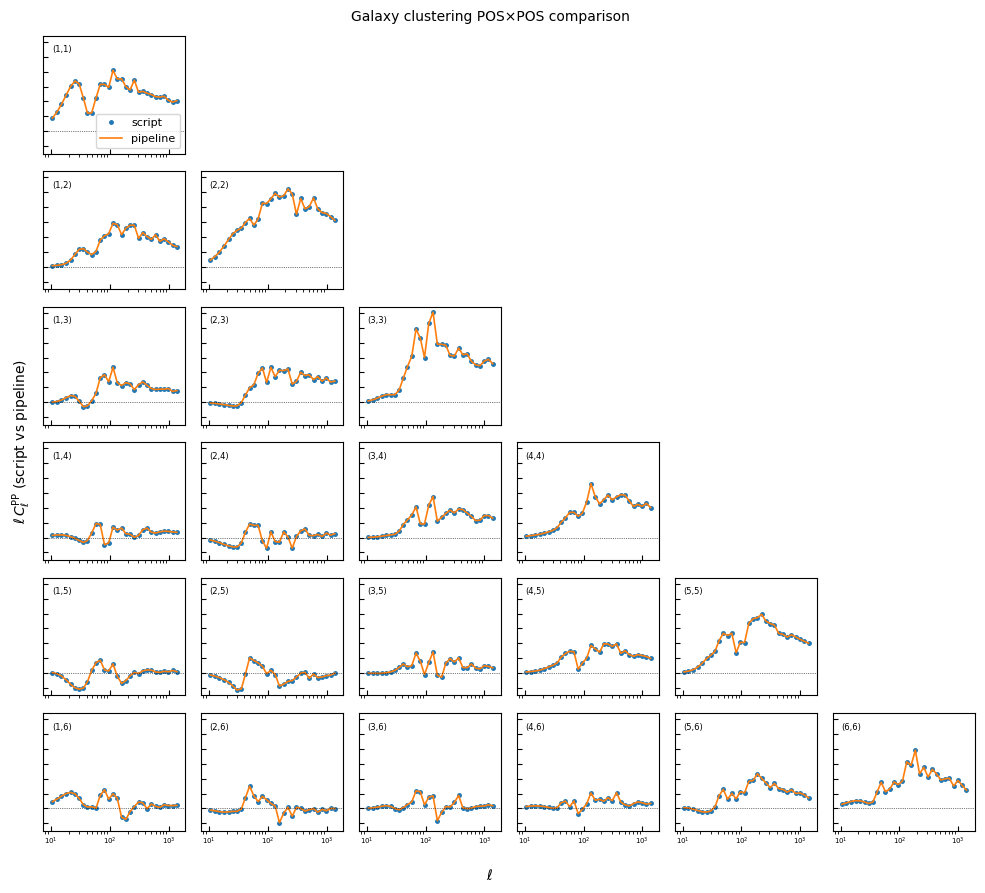

In [44]:
n_tomo = 6
cls_script=cls_binned
fig, ax = plt.subplots(n_tomo, n_tomo, figsize=(10, 9), sharex=True, sharey=True)

for i in range(1, n_tomo + 1):

    # hide lower triangle
    for j in range(1, i):
        ax[j - 1, i - 1].axis("off")

    for j in range(i, n_tomo + 1):

        key = ("POS", "POS", i, j)

        v_script = cls_script[key]
        v_pipe   = cls_pipe[key]

        ell_b = np.array(v_script.ell)
        d_script = np.array(v_script)
        d_pipe   = np.array(v_pipe)

        # --- plotting ---
        ax[j - 1, i - 1].plot(
            ell_b,
            ell_b * d_script,
            "o",
            color="C0",
            ms=2.5,
            label="script" if (i == 1 and j == 1) else None,
        )

        ax[j - 1, i - 1].plot(
            ell_b,
            ell_b * d_pipe,
            color="C1",
            lw=1.2,
            label="pipeline" if (i == 1 and j == 1) else None,
        )

        # zero line
        ax[j - 1, i - 1].axhline(0, color="k", lw=0.5, ls=":")

        # bin label
        ax[j - 1, i - 1].text(
            0.06, 0.92, f"({i},{j})",
            transform=ax[j - 1, i - 1].transAxes,
            fontsize=6,
            va="top",
        )

        ax[j - 1, i - 1].tick_params(labelsize=5, direction="in")

# --- axes formatting ---
ax[0, 0].set_xscale("log")
ax[0, 0].set_xlim(ell_b[0] * 0.7, ell_b[-1] * 1.4)

ax[0, 0].xaxis.get_major_locator().set_params(numticks=99)
ax[0, 0].xaxis.get_minor_locator().set_params(
    numticks=99,
    subs=np.arange(0.1, 1.0, 0.1)
)

plt.setp(ax.flat, yticklabels=[])

fig.supxlabel(r"$\ell$", fontsize=10)
fig.supylabel(r"$\ell\,C_\ell^{\rm PP}$ (script vs pipeline)", fontsize=10)

ax[0, 0].legend(fontsize=8)

fig.suptitle("Galaxy clustering POS×POS comparison", fontsize=10)

plt.tight_layout()
plt.show()

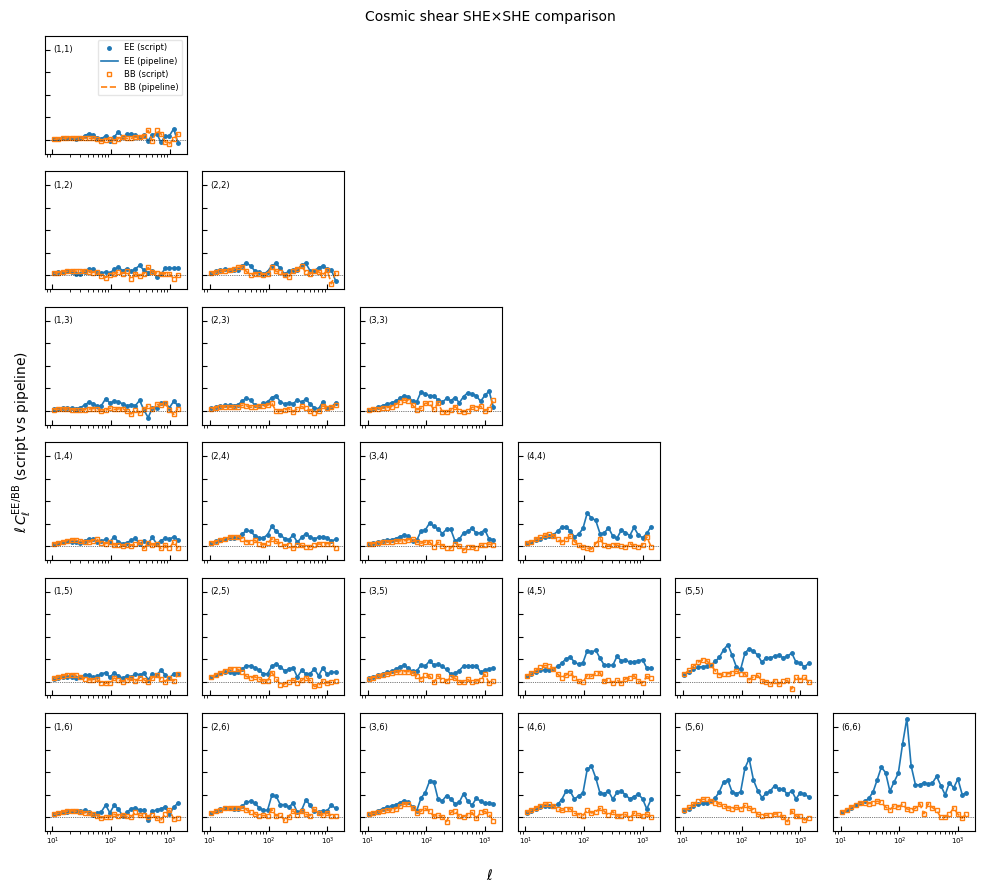

In [46]:
fig, ax = plt.subplots(n_tomo, n_tomo, figsize=(10, 9), sharex=True, sharey=True)

for i in range(1, n_tomo + 1):

    # hide lower triangle
    for j in range(1, i):
        ax[j - 1, i - 1].axis("off")

    for j in range(i, n_tomo + 1):

        key = ("SHE", "SHE", i, j)

        v_script = cls_script[key]
        v_pipe   = cls_pipe[key]

        ell_b = np.array(v_script.ell)

        # extract EE / BB
        ee_script = np.array(v_script[0, 0])
        bb_script = np.array(v_script[1, 1])

        ee_pipe = np.array(v_pipe[0, 0])
        bb_pipe = np.array(v_pipe[1, 1])

        # --- EE ---
        ax[j - 1, i - 1].plot(
            ell_b,
            ell_b * ee_script,
            "o",
            color="C0",
            ms=2.5,
            label="EE (script)" if (i == 1 and j == 1) else None,
        )

        ax[j - 1, i - 1].plot(
            ell_b,
            ell_b * ee_pipe,
            color="C0",
            lw=1.2,
            label="EE (pipeline)" if (i == 1 and j == 1) else None,
        )

        # --- BB ---
        ax[j - 1, i - 1].plot(
            ell_b,
            ell_b * bb_script,
            "s",
            color="C1",
            ms=2.5,
            markerfacecolor="none",
            label="BB (script)" if (i == 1 and j == 1) else None,
        )

        ax[j - 1, i - 1].plot(
            ell_b,
            ell_b * bb_pipe,
            color="C1",
            lw=1.2,
            ls="--",
            label="BB (pipeline)" if (i == 1 and j == 1) else None,
        )

        # zero line
        ax[j - 1, i - 1].axhline(0, color="k", lw=0.5, ls=":")

        # bin label
        ax[j - 1, i - 1].text(
            0.06, 0.92, f"({i},{j})",
            transform=ax[j - 1, i - 1].transAxes,
            fontsize=6,
            va="top",
        )

        ax[j - 1, i - 1].tick_params(labelsize=5, direction="in")


# --- axes formatting ---
ax[0, 0].set_xscale("log")
ax[0, 0].set_xlim(ell_b[0] * 0.7, ell_b[-1] * 1.4)

ax[0, 0].xaxis.get_major_locator().set_params(numticks=99)
ax[0, 0].xaxis.get_minor_locator().set_params(
    numticks=99,
    subs=np.arange(0.1, 1.0, 0.1)
)

plt.setp(ax.flat, yticklabels=[])

fig.supxlabel(r"$\ell$", fontsize=10)
fig.supylabel(r"$\ell\,C_\ell^{\rm EE/BB}$ (script vs pipeline)", fontsize=10)

ax[0, 0].legend(fontsize=6, loc="upper right", framealpha=0.5)

fig.suptitle("Cosmic shear SHE×SHE comparison", fontsize=10)

plt.tight_layout()
plt.show()

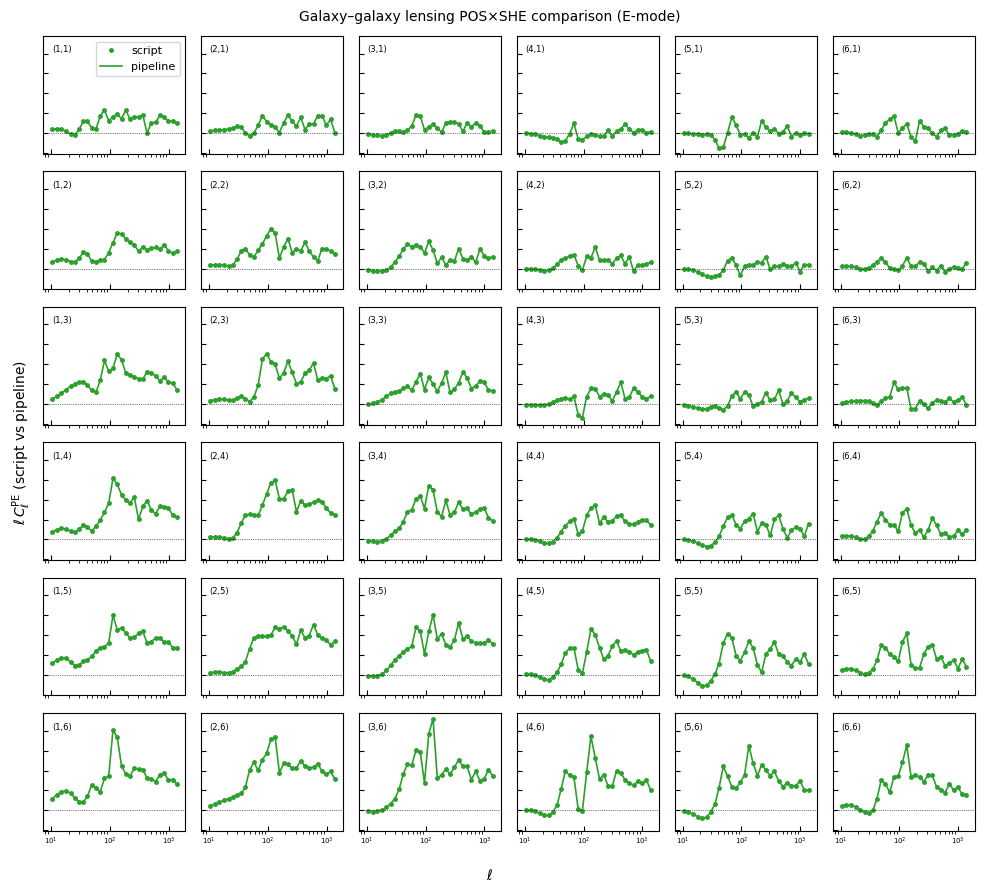

In [47]:
fig, ax = plt.subplots(n_tomo, n_tomo, figsize=(10, 9), sharex=True, sharey=True)

for i in range(1, n_tomo + 1):
    for j in range(1, n_tomo + 1):

        key = ("POS", "SHE", i, j)

        if key not in cls_script or key not in cls_pipe:
            ax[j - 1, i - 1].axis("off")
            continue

        v_script = cls_script[key]
        v_pipe   = cls_pipe[key]

        ell_b = np.array(v_script.ell)

        # E-mode only (index 0)
        e_script = np.array(v_script[0])
        e_pipe   = np.array(v_pipe[0])

        # --- plotting ---
        ax[j - 1, i - 1].plot(
            ell_b,
            ell_b * e_script,
            "o",
            color="C2",
            ms=2.5,
            label="script" if (i == 1 and j == 1) else None,
        )

        ax[j - 1, i - 1].plot(
            ell_b,
            ell_b * e_pipe,
            color="C2",
            lw=1.2,
            label="pipeline" if (i == 1 and j == 1) else None,
        )

        # zero line
        ax[j - 1, i - 1].axhline(0, color="k", lw=0.5, ls=":")

        # bin label
        ax[j - 1, i - 1].text(
            0.06, 0.92, f"({i},{j})",
            transform=ax[j - 1, i - 1].transAxes,
            fontsize=6,
            va="top",
        )

        ax[j - 1, i - 1].tick_params(labelsize=5, direction="in")


# --- axes formatting ---
ax[0, 0].set_xscale("log")
ax[0, 0].set_xlim(ell_b[0] * 0.7, ell_b[-1] * 1.4)

ax[0, 0].xaxis.get_major_locator().set_params(numticks=99)
ax[0, 0].xaxis.get_minor_locator().set_params(
    numticks=99,
    subs=np.arange(0.1, 1.0, 0.1)
)

plt.setp(ax.flat, yticklabels=[])

fig.supxlabel(r"$\ell$", fontsize=10)
fig.supylabel(r"$\ell\,C_\ell^{\rm PE}$ (script vs pipeline)", fontsize=10)

ax[0, 0].legend(fontsize=8)

fig.suptitle("Galaxy–galaxy lensing POS×SHE comparison (E-mode)", fontsize=10)

plt.tight_layout()
plt.show()